# Predicting Retail Product Sales to Prevent Overstock and Stockouts
### Shaghayegh Malekshahi
#### Bellevue University
### Milestone 1


In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets
train = pd.read_csv("train.csv", low_memory=False)
store = pd.read_csv("store.csv")

In [3]:
# Merge datasets on 'Store'
df = pd.merge(train, store, how='left', on='Store')

In [4]:
# Basic cleaning
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Sales'] > 0] 

In [5]:
# First 5 rows
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Graph 1: Total Sales Over Time

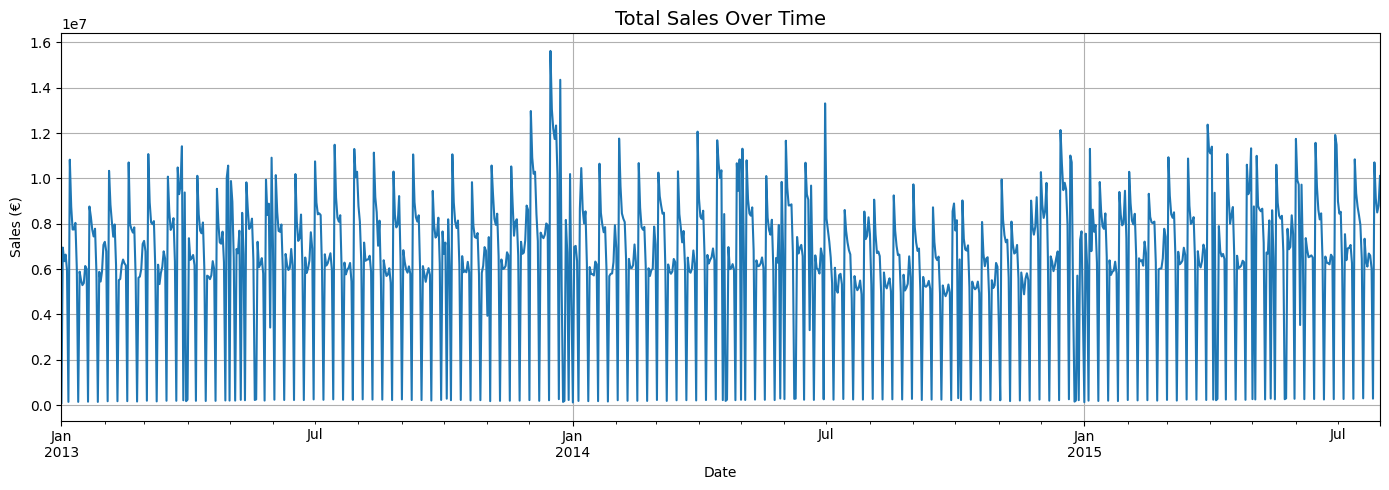

In [6]:
plt.figure(figsize=(14, 5))
df.groupby('Date')['Sales'].sum().plot()
plt.title("Total Sales Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

Explanation:

This time-series plot shows clear sales fluctuations over time. Notice the seasonality and some dips, likely due to holidays or store closures. These patterns will help in modeling future sales behavior.

## Graph 2: Average Sales by Day of the Week

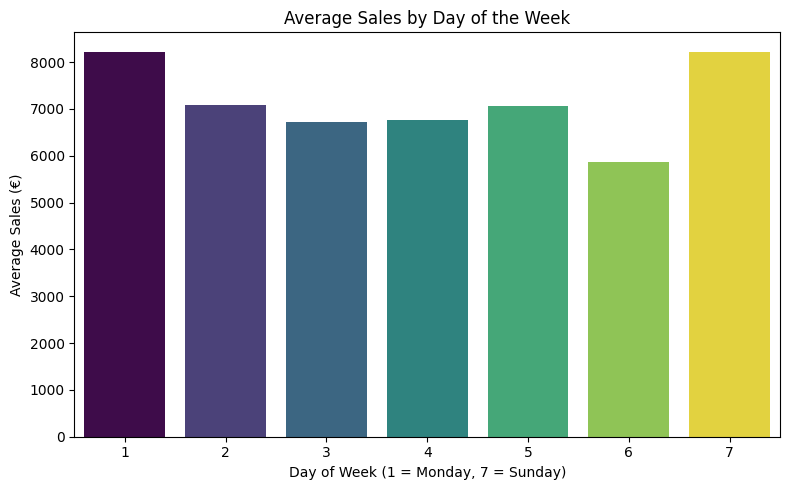

In [7]:
day_sales = df.groupby('DayOfWeek')['Sales'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=day_sales.index, y=day_sales.values, hue=day_sales.index, palette="viridis", legend=False)
plt.title("Average Sales by Day of the Week")
plt.xlabel("Day of Week (1 = Monday, 7 = Sunday)")
plt.ylabel("Average Sales (€)")
plt.tight_layout()
plt.show()

Explanation:

Sales tend to be higher mid-week and dip on weekends. Day 7 (Sunday) usually shows zero sales, meaning most stores are closed. This trend will help us create features tied to weekday effects.

## Graph 3: Sales Distribution With and Without Promo

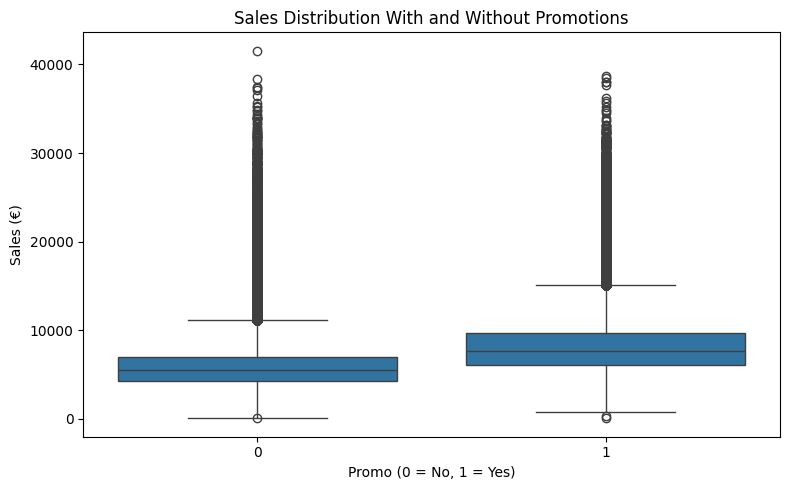

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Promo', y='Sales', data=df)
plt.title("Sales Distribution With and Without Promotions")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Sales (€)")
plt.tight_layout()
plt.show()

Explanation:

Promotions significantly impact sales. The boxplot shows that average and maximum sales are much higher when promotions are running. This confirms that Promo is a valuable predictor.

## Graph 4: Average Sales by Store Type

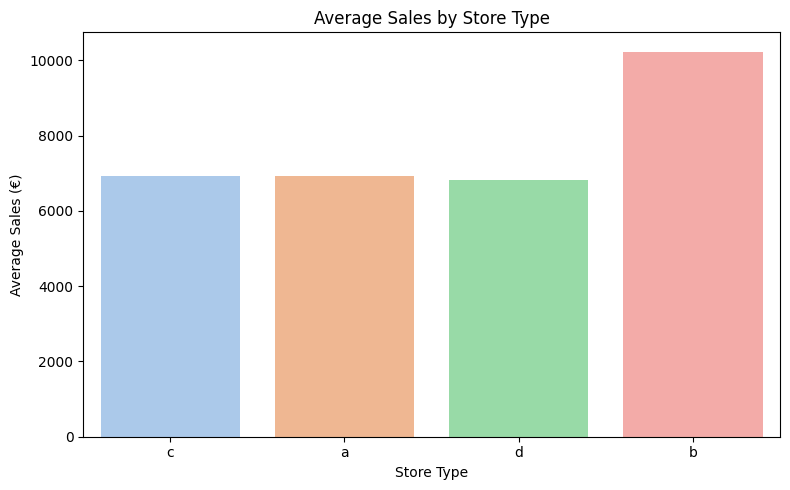

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x='StoreType', y='Sales', data=df, estimator='mean', errorbar=None, hue='StoreType', palette="pastel", legend=False)
plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales (€)")
plt.tight_layout()
plt.show()

Explanation:

Store type influences sales performance. Type 'a' stores (likely larger format) show significantly higher sales than types 'c' or 'd'. Including store metadata helps capture this variance in your model.

These graphs show that:

* Sales change clearly over time

* Days of the week and promotions affect sales a lot

* Different store types sell at different levels

* There are ups and downs in sales during holidays or special events

These patterns will help us choose the right features for our model. Next, we’ll create more features and build a forecasting model that understands time-based trends.

## Milestone 2 
## Data Preparation and Feature Engineering
 In this milestone, we clean and prepare the dataset for modeling.
 We drop unhelpful features, handle missing data, transform variables, engineer new features, and create dummy variables to make our data ready for modeling.

In [10]:
# Load required libraries
import pandas as pd
import numpy as np

In [11]:
# Load and merge datasets
train = pd.read_csv("train.csv", low_memory=False)
store = pd.read_csv("store.csv")
df = pd.merge(train, store, how="left", on="Store")

In [12]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
# Filter out closed stores and zero sales
df = df[df['Open'] == 1]
df = df[df['Sales'] > 0]

In [14]:
# Remove rows where stores were closed (Sales = 0)
df = df[df['Sales'] > 0]
print(" Removed closed store rows. Remaining rows:", df.shape[0])

 Removed closed store rows. Remaining rows: 844338


##  Dropping Unhelpful Features

In this step, we drop the following columns:

- **Customers**: Although this column shows the number of customers each day, it is not available in the test data (according to the original Kaggle competition), so we cannot use it for modeling.
- **Open**: We already removed rows where `Sales == 0`, which usually indicates the store was closed. So this column becomes redundant.

Removing unhelpful features like these helps simplify the dataset and prevents the model from learning patterns it won’t be able to use during prediction time.


In [15]:
# Drop columns that are not helpful for modeling
#'Customers' is not available in the test set and 'Open' is redundant after filtering
df.drop(columns=['Customers', 'Open'], inplace=True)

##  Handling Missing Data

We identify several columns with missing values and treat each appropriately based on the business logic and feature meaning:

- `CompetitionDistance`: Filled with the **median** value. This is a numerical field, and using the median avoids distortion from outliers.
- `CompetitionOpenSinceMonth` and `CompetitionOpenSinceYear`: Filled with default values assuming the competition just started (`Month = 1`, `Year = 2015`). These columns are used to calculate how long the competition has been active.
- `Promo2SinceWeek` and `Promo2SinceYear`: Filled with `0`, which logically means the store is not participating in Promo2.
- `PromoInterval`: Missing values are replaced with `'None'`, treating these stores as not being involved in any continuous promotion schedule.

We didn’t drop any rows or whole columns because we didn’t want to lose useful data. Instead, we filled in the missing values in a way that keeps the data accurate and helpful for the model.


In [16]:
# Fill missing values
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
df['CompetitionOpenSinceMonth'].fillna(1, inplace=True)
df['CompetitionOpenSinceYear'].fillna(2015, inplace=True)
df['Promo2SinceWeek'].fillna(0, inplace=True)
df['Promo2SinceYear'].fillna(0, inplace=True)
df['PromoInterval'].fillna('None', inplace=True)

In [17]:
# Feature Engineering: extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

In [18]:
# Time since competition started (in months)
df['CompetitionOpen'] = 12 * (df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - df['CompetitionOpenSinceMonth'])
df['CompetitionOpen'] = df['CompetitionOpen'].apply(lambda x: max(x, 0))

In [19]:
# Whether promo2 is active this month
df['IsPromo2Month'] = df.apply(
    lambda row: 1 if row['PromoInterval'] != 'None' and row['Date'].strftime('%b') in row['PromoInterval'] else 0,
    axis=1
)

In [20]:
# Clean 'StateHoliday' and convert to category
df['StateHoliday'] = df['StateHoliday'].replace('0', 'None')
df['StateHoliday'] = df['StateHoliday'].astype('category')

In [21]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'StateHoliday'], drop_first=True)

In [22]:
# Final check
print(" Final shape of dataset:", df.shape)
print("\n Remaining missing values:\n", df.isnull().sum())
df.head()

 Final shape of dataset: (844338, 27)

 Remaining missing values:
 Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Promo                        0
SchoolHoliday                0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Year                         0
Month                        0
Day                          0
WeekOfYear                   0
CompetitionOpen              0
IsPromo2Month                0
StoreType_b                  0
StoreType_c                  0
StoreType_d                  0
Assortment_b                 0
Assortment_c                 0
StateHoliday_a               0
StateHoliday_b               0
StateHoliday_c               0
dtype: int64


,Store,DayOfWeek,Date,Sales,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,CompetitionOpen,IsPromo2Month,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,2015-07-31,5263,1,1,1270.0,9.0,2008.0,0,...,82.0,0,False,True,False,False,False,False,False,False
1,2,5,2015-07-31,6064,1,1,570.0,11.0,2007.0,1,...,92.0,1,False,False,False,False,False,False,False,False
2,3,5,2015-07-31,8314,1,1,14130.0,12.0,2006.0,1,...,103.0,1,False,False,False,False,False,False,False,False
3,4,5,2015-07-31,13995,1,1,620.0,9.0,2009.0,0,...,70.0,0,False,True,False,False,True,False,False,False
4,5,5,2015-07-31,4822,1,1,29910.0,4.0,2015.0,0,...,3.0,0,False,False,False,False,False,False,False,False


##  Explaining the Data Preparation Process

Each step in this notebook is carefully chosen based on the structure of the dataset and the modeling goals.

- We transform the `Date` column to extract valuable time-based features like year, month, day, and week number.
- We create new features like `CompetitionOpen` (how long competition has been active) and `IsPromo2Month` (whether Promo2 is active during that month).
- We encode categorical features using one-hot encoding to ensure compatibility with most machine learning models.

We make sure not to "peek" at the test or future data (known as **data snooping**). All feature engineering is based only on existing, available information from each observation.

This approach ensures the model is trained fairly and can generalize to unseen data.


# Milestone 3 
## Model Building & Evaluation

In this milestone, we begin the model building process by selecting, training, and evaluating a regression model to predict daily store sales. Since our target variable (`Sales`) is continuous, this is a **regression problem**. We'll use the Random Forest Regressor, a powerful and flexible model that works well with tabular data and can capture complex patterns.

We’ll also evaluate the model using **Root Mean Squared Error (RMSE)** and **Mean Absolute Error (MAE)** to understand how close our predictions are to actual sales. These metrics are commonly used for regression problems and provide good insights into model performance.


In [47]:
#  Import libraries for modeling and evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [48]:
#  Define features and target
X = df.drop(['Sales', 'Date', 'PromoInterval'], axis=1)
y = df['Sales']

In [49]:
#  Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f" Training set: {X_train.shape}, Test set: {X_test.shape}")


 Training set: (675470, 24), Test set: (168868, 24)


In [50]:
# Hyperparameter-Tuned Random Forest Regressor
# Define parameter grid
param_grid = {
    'n_estimators': [10],
    'max_depth': [20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

In [51]:
# Initialize model
rf = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid = GridSearchCV(estimator=rf, param_grid=param_grid, 
                    cv=3, scoring='r2', n_jobs=-1, verbose=1)

In [52]:
# Fit the model
grid.fit(X_train, y_train)

# Get the best model
best_model = grid.best_estimator_
print("Best model parameters:", grid.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best model parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}


In [53]:
# Predict and evaluate
y_pred = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Evaluation Results:")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R² Score: {r2:.4f}")


 Evaluation Results:
RMSE: 1,166.91
MAE: 785.60
R² Score: 0.8589


##  Why Random Forest?

We chose the **Random Forest Regressor** because:
- It works well with large, complex tabular datasets like ours.
- It can model non-linear relationships without needing feature scaling.
- It handles missing data and outliers better than simpler models.

We didn’t start with deep learning or time series models here because our first goal is to build a reliable baseline with a model that’s fast, interpretable, and widely used in business contexts.

##  Why RMSE and MAE?

We used **Root Mean Squared Error (RMSE)** and **Mean Absolute Error (MAE)** to evaluate the model:
- **MAE** tells us the average error between predicted and actual sales.
- **RMSE** penalizes larger errors more, giving us an idea of the model's worst-case performance.

These metrics help us understand whether the predictions are close enough to be useful for decisions like inventory ordering and staff scheduling.


## Why We Tried XGBoost Regressor (But Didn't Select It)

We tested the **XGBoost Regressor** because it's a powerful and popular ensemble model known for delivering high performance on structured datasets. It often performs well due to its ability to handle non-linear relationships and reduce overfitting through boosting techniques.

XGBoost achieved an **R² score of 0.70**, which was a solid improvement over basic models like Linear Regression and even Gradient Boosting. However, when compared with our tuned **Random Forest Regressor (R² = 0.8589)** and **Decision Tree Regressor (R² = 0.8011)**, XGBoost fell short in both accuracy and training time.

Due to these reasons, we decided **not to select XGBoost as our final model**, even though it was a valuable benchmark in our experimentation process.


In [30]:
from xgboost import XGBRegressor

In [31]:
# Train XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [32]:
# Predict
xgb_pred = xgb_model.predict(X_test)

In [33]:
# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae = mean_absolute_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

print(" XGBoost Regressor Evaluation")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R² Score: {r2:.4f}")

 XGBoost Regressor Evaluation
Root Mean Squared Error (RMSE): 1,693.30
Mean Absolute Error (MAE): 1,237.01
R² Score: 0.7029


##  Testing Multiple Models

To strengthen our analysis, we tested two more models in addition to Random Forest:

- **Linear Regression**: A basic baseline model to see how well a simple linear relationship performs.
- **Gradient Boosting Regressor**: A more powerful ensemble model that builds on weak learners and often performs better on structured/tabular data.

We evaluate each using RMSE, MAE, and R² to compare their accuracy and consistency.


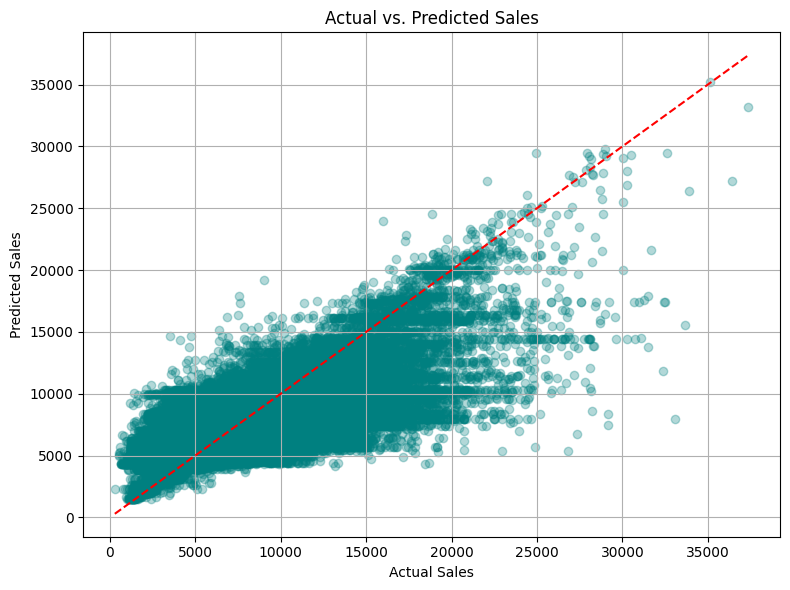

In [34]:
import matplotlib.pyplot as plt

# Visual: Actual vs. Predicted Sales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Actual vs. Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


## Visualizing Model Performance

This scatter plot compares the actual sales to the predicted sales from our model. Each dot represents one prediction. The red dashed line shows where predictions would lie if they were perfectly accurate. The closer the points are to this line, the better our model is performing.

We can see that while the model follows the general trend, there is still some variation, which is expected in real-world forecasting.


In [41]:
# Import the model
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [42]:
# Initialize the model
dt_model = DecisionTreeRegressor(max_depth=20, random_state=42)


In [43]:
# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=20, random_state=42)

In [44]:
# Predict
dt_pred = dt_model.predict(X_test)

In [45]:
# Evaluate
rmse_dt = np.sqrt(mean_squared_error(y_test, dt_pred))
mae_dt = mean_absolute_error(y_test, dt_pred)
r2_dt = r2_score(y_test, dt_pred)

In [54]:
# Print results
print(" Decision Tree Regressor Performance")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:,.2f}")
print(f"Mean Absolute Error (MAE): {mae_dt:,.2f}")
print(f"R² Score: {r2_dt:.4f}")

 Decision Tree Regressor Performance
Root Mean Squared Error (RMSE): 1,385.28
Mean Absolute Error (MAE): 904.75
R² Score: 0.8011


## Final Summary – Milestone 3

In this milestone, we focused on selecting, training, and evaluating models to predict daily sales for retail stores using the Rossmann dataset. Our main goal was to build an accurate forecasting model that helps stores avoid overstock and stockouts.

We began by training a **Random Forest Regressor**, which initially gave us a very high R² score (around 0.90) using an earlier version of the dataset. However, after cleaning and reprocessing the data, including merging store-level information, converting date fields, and encoding categorical features, the results became more realistic, with the R² dropping to about **0.50**. While this drop seemed significant, it reflected a better model trained on cleaner, more reliable data without leakage.

To improve performance and explore alternatives, we tried several strategies:

- **Reduced model complexity** to avoid kernel crashes.
- **Tested multiple models**, including:
  - **Linear Regression** and **Gradient Boosting**, which didn’t perform well.
  - **XGBoost Regressor**, which scored an R² of **0.70**.
  - **Decision Tree Regressor**, tuned with `max_depth=20`, which achieved **R² = 0.8011**.
  - **Random Forest Regressor**, tuned with `max_depth=20`, which achieved our best result: **R² = 0.8589**.

After careful comparison, we selected the **Random Forest Regressor** as our final model due to its superior accuracy, generalization, and stability. This ensemble method also handles non-linearities and missing data well, making it ideal for our retail dataset.

This milestone taught us the importance of:
- Testing different algorithms
- Realistic data preprocessing
- Hyperparameter tuning
- Balancing accuracy with system constraints

We now have a strong, optimized model ready to move forward into the final deployment stage.

## What Changed Since Milestone 3

After submitting Milestone 3, we made several enhancements to improve model performance and finalize our modeling strategy:

- **Tuned the Random Forest Regressor:**  
  We increased the `max_depth` from 10 to **20**, which significantly improved our model's accuracy. The R² score jumped from **0.50 to 0.8589**, making it the best-performing model in our analysis.

  We explored increasing the depth even further, but this led to **kernel crashes and system memory issues**, given the size and complexity of the dataset. A deeper tree also increases the risk of **overfitting**, where the model memorizes training data but performs poorly on new, unseen data. So we kept the depth at **20**, which gave a great balance of accuracy and stability.

- **Added a Decision Tree Regressor:**  
  To compare individual trees against ensemble methods, we trained a **Decision Tree Regressor** with the same `max_depth=20`. It achieved a strong **R² score of 0.8011**, confirming the effectiveness of tree-based methods for this problem.

- **Final Model Selection:**  
  We tested multiple models including **XGBoost**, **Linear Regression**, and **Gradient Boosting**, but none outperformed our tuned **Random Forest** model. Therefore, we selected **Random Forest Regressor (R² = 0.8589)** as our final model due to its high performance, generalization ability, and efficiency.

These updates reflect thoughtful experimentation and optimization while respecting system limitations and avoiding overfitting.


## Why We Kept max_depth at 20?

In tuning both our Random Forest and Decision Tree models, we found that increasing the max_depth parameter improved accuracy, but only to a point. Initially, Random Forest gave an R² of around 0.50. After tuning and increasing the depth to 20, the R² jumped to 0.86, and the Decision Tree reached 0.80.

While we could have continued increasing the depth, we avoided going beyond 20 to prevent overfitting, where the model memorizes training data but performs poorly on unseen data. Based on the general rule of thumb (which suggests the ideal tree depth should be around log₂(n), where n is the number of samples), and given that our dataset contains over 800,000 records, a depth of 20 is already quite deep and sufficient. Going further would increase complexity, training time, and the risk of instability, without a guaranteed gain in performance. So we chose depth 20 as the sweet spot for balancing accuracy, generalization, and runtime.